<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [3]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [8]:
# Read the CSV file

import pandas as pd
df = pd.read_csv('survey_data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [10]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [12]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [14]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [16]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [18]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


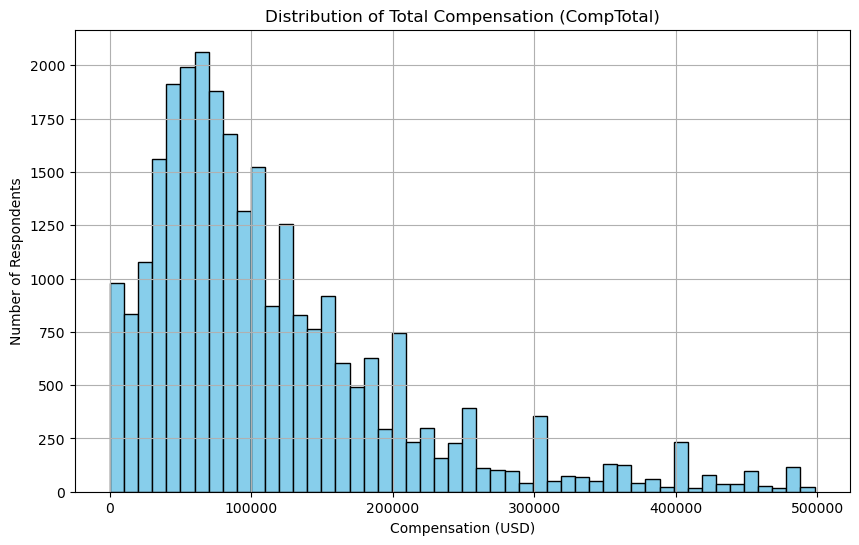

In [20]:
## Write your code here

# Connect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Query the CompTotal column from the main table
QUERY = "SELECT CompTotal FROM main"
df_comp = pd.read_sql_query(QUERY, conn)

# Close the connection
conn.close()

# Drop missing values (CompTotal is likely to have NaNs)
df_comp = df_comp.dropna()

# Optional: filter out extremely high values to make the plot clearer
df_comp = df_comp[df_comp['CompTotal'] < 500000]

# Plot the histogram
plt.figure(figsize=(10,6))
plt.hist(df_comp['CompTotal'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Compensation (CompTotal)')
plt.xlabel('Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.grid(True)
plt.show()

**Box Plots**

Plot a box plot of Age.


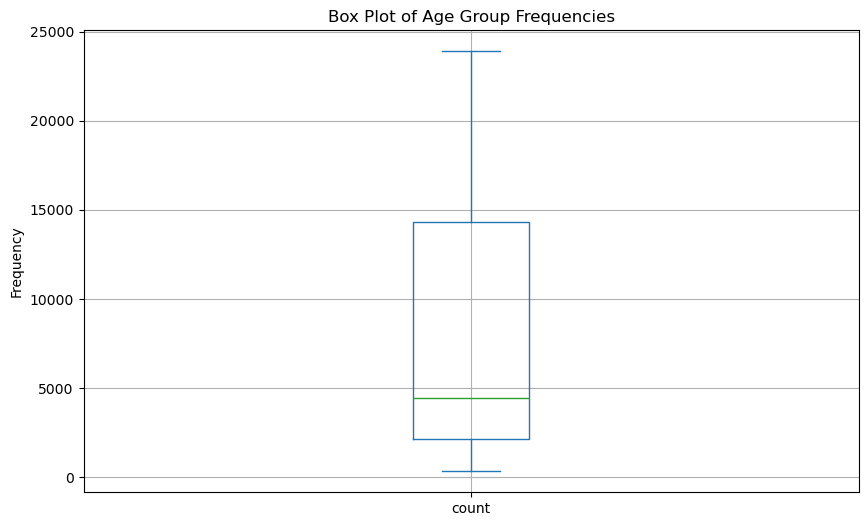

In [22]:
## Write your code here

#Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# Read Age column
QUERY = "SELECT Age FROM main"
df_age = pd.read_sql_query(QUERY, conn)
conn.close()

# Drop missing values
df_age = df_age.dropna()

# Plot boxplot of age category frequencies (not true numerical boxplot)
plt.figure(figsize=(10, 6))
df_age['Age'].value_counts().plot(kind='box')
plt.title('Box Plot of Age Group Frequencies')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


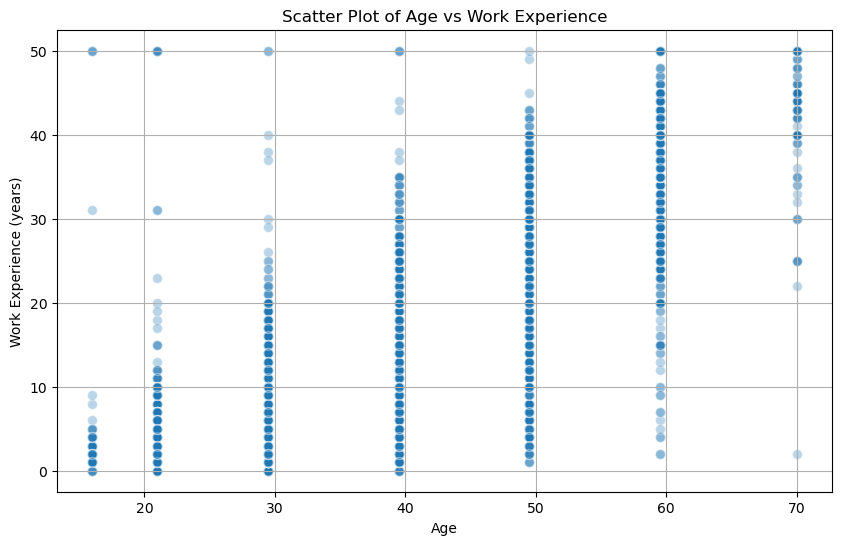

In [26]:
## Write your code here

#Connect to the database
conn = sqlite3.connect('survey-data.sqlite')

# Query Age and WorkExp columns
QUERY = "SELECT Age, WorkExp FROM main"
df = pd.read_sql_query(QUERY, conn)
conn.close()

# Map age ranges to numeric midpoints
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}

# Apply mapping
df['AgeNumeric'] = df['Age'].map(age_map)

# Drop rows with missing AgeNumeric or WorkExp
df_clean = df.dropna(subset=['AgeNumeric', 'WorkExp'])

# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df_clean['AgeNumeric'], df_clean['WorkExp'], alpha=0.3, edgecolors='w', s=50)
plt.title('Scatter Plot of Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience (years)')
plt.grid(True)
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


Unique values in TimeSearching: [None '30-60 minutes a day' '60-120 minutes a day' '15-30 minutes a day'
 'Less than 15 minutes a day' 'Over 120 minutes a day']


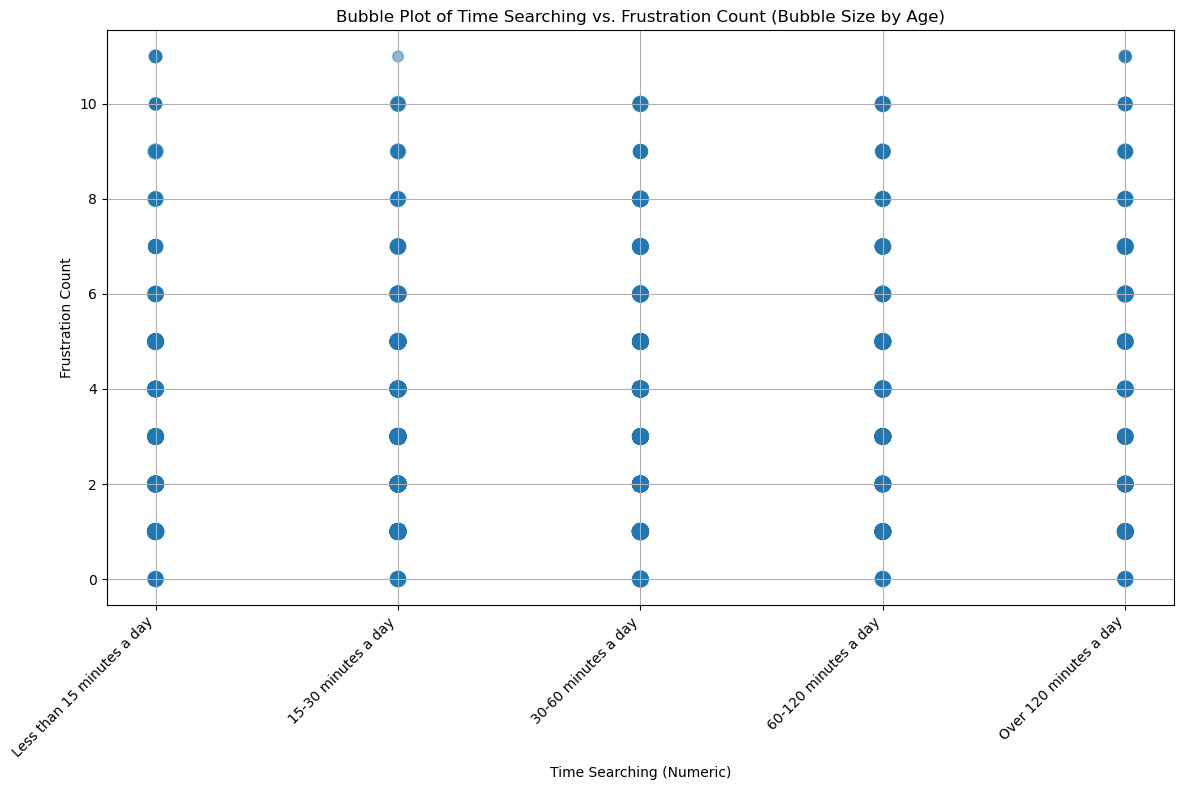

In [42]:
## Write your code here
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Query the TimeSearching, Frustration, and Age columns
QUERY = """
SELECT TimeSearching, Frustration, Age
FROM main
"""
bubble_df = pd.read_sql_query(QUERY, conn)

# Close the connection
conn.close()

# Use the existing age_mapping to convert Age to numerical for bubble size
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': (18 + 24) / 2,
    '25-34 years old': (25 + 34) / 2,
    '35-44 years old': (35 + 44) / 2,
    '45-54 years old': (45 + 54) / 2,
    '55-64 years old': (55 + 64) / 2,
    '65 years or older': 65,
    'Prefer not to say': None
}
bubble_df['Age_Numeric'] = bubble_df['Age'].map(age_mapping)

# Handle categorical data for 'TimeSearching' and 'Frustration' for plotting.
# For simplicity, let's map these to numerical values. We'll need to see the unique values first.
# Let's check the unique values in these columns to decide on a mapping.
print("Unique values in TimeSearching:", bubble_df['TimeSearching'].unique())
#print("Unique values in Frustration:", bubble_df['Frustration'].unique())

# Based on the unique values, let's create a simple ordinal mapping.
# Corrected mapping based on the printed unique values
time_searching_mapping = {
    'Less than 15 minutes a day': 0,
    '15-30 minutes a day': 1,
    '30-60 minutes a day': 2,
    '60-120 minutes a day': 3,
    'Over 120 minutes a day': 4,
    None: None # Handle None values
}

# Frustration column seems to contain combined values. Let's simplify for plotting.
# A simple approach is to count the number of frustrations listed for each entry.
bubble_df['Frustration_Count'] = bubble_df['Frustration'].apply(lambda x: len(str(x).split(';')) if pd.notna(x) else 0)


bubble_df['TimeSearching_Numeric'] = bubble_df['TimeSearching'].map(time_searching_mapping)
# We'll use Frustration_Count for the y-axis


# Drop rows with NaN values in the columns needed for the bubble plot
bubble_df.dropna(subset=['TimeSearching_Numeric', 'Frustration_Count', 'Age_Numeric'], inplace=True)

# Create the bubble plot
plt.figure(figsize=(12, 8))
# Scale the bubble sizes for better visualization
size = bubble_df['Age_Numeric'] * 2 # Adjust scaling factor as needed (reduced from 10 to 2)
plt.scatter(bubble_df['TimeSearching_Numeric'], bubble_df['Frustration_Count'], s=size, alpha=0.5)

plt.title('Bubble Plot of Time Searching vs. Frustration Count (Bubble Size by Age)')
plt.xlabel('Time Searching (Numeric)') # Label based on numeric mapping
plt.ylabel('Frustration Count')   # Label based on count

# Add ticks and labels based on original categorical values for better understanding
plt.xticks(list(time_searching_mapping.values())[:-1], list(time_searching_mapping.keys())[:-1], rotation=45, ha='right')
# For Frustration_Count, the y-axis labels will be the counts themselves.


plt.grid(True)
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


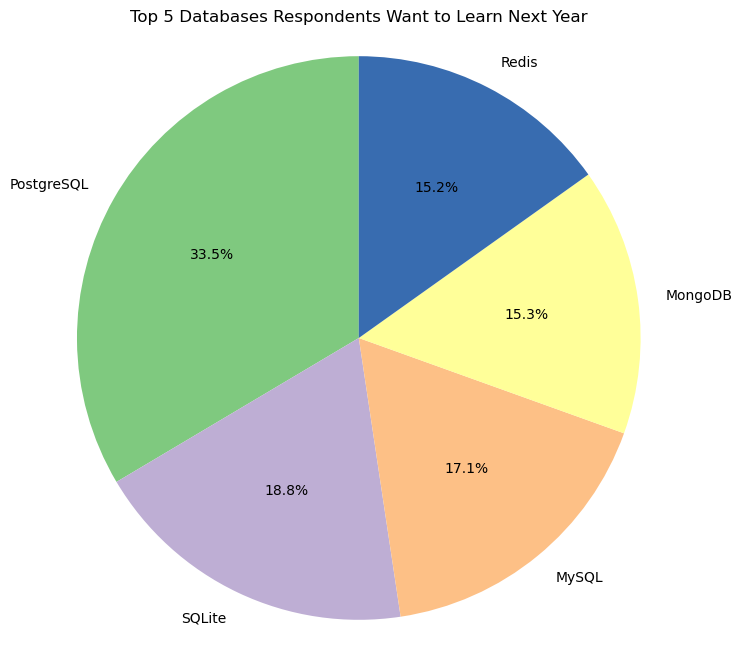

In [54]:
# Connect to the database and query the column
conn = sqlite3.connect('survey-data.sqlite')
QUERY = "SELECT DatabaseWantToWorkWith FROM main"
df = pd.read_sql_query(QUERY, conn)
conn.close()

# Drop missing values
df = df.dropna(subset=['DatabaseWantToWorkWith'])

# Split the semicolon-separated strings into individual database names
all_databases = df['DatabaseWantToWorkWith'].str.split(';').explode()

# Count the occurrences of each database
database_counts = all_databases.value_counts()

# Get top 5 databases
top5 = database_counts.head(5)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Accent.colors)
plt.title('Top 5 Databases Respondents Want to Learn Next Year')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


          TimeSearching         TimeAnswering              Age
1                  None                  None  35-44 years old
6                  None                  None  35-44 years old
9                  None                  None  35-44 years old
10  30-60 minutes a day  60-120 minutes a day  35-44 years old
12  30-60 minutes a day   15-30 minutes a day  35-44 years old
          TimeSearching         TimeAnswering              Age  \
1                  None                  None  35-44 years old   
6                  None                  None  35-44 years old   
9                  None                  None  35-44 years old   
10  30-60 minutes a day  60-120 minutes a day  35-44 years old   
12  30-60 minutes a day   15-30 minutes a day  35-44 years old   

    TimeSearching_Numeric  TimeAnswering_Numeric  
1                     NaN                    NaN  
6                     NaN                    NaN  
9                     NaN                    NaN  
10                   

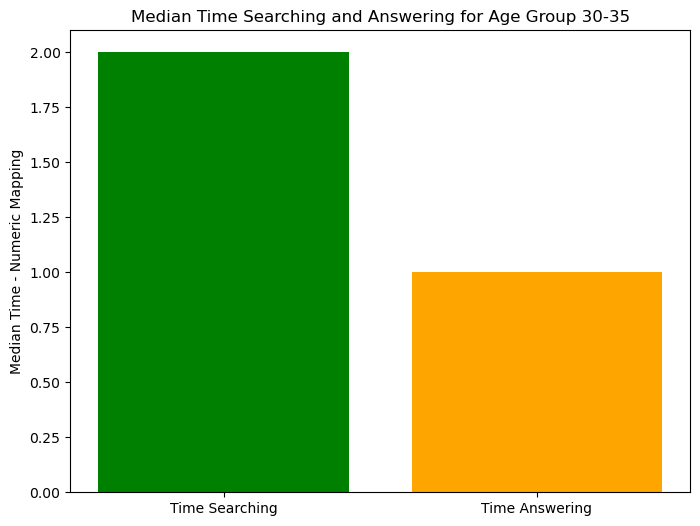

In [64]:
## Write your code here

## Write your code here
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Construct a SQL query to select 'TimeSearching', 'TimeAnswering', and 'Age' columns
QUERY = """
SELECT TimeSearching, TimeAnswering, Age
FROM main
"""
time_analysis_df = pd.read_sql_query(QUERY, conn)

# Close the connection
conn.close()

# Filter the DataFrame for the age groups that cover 30 to 35
# Based on the unique age groups seen earlier, these are '25-34 years old' and '35-44 years old'
age_groups_to_filter = ['25-34 years old', '35-44 years old']
filtered_time_df = time_analysis_df[time_analysis_df['Age'].isin(age_groups_to_filter)].copy()

# Display the first few rows of the filtered data
print(filtered_time_df.head())

# Define the mapping for categorical time values
time_mapping = {
    'Less than 15 minutes a day': 0,
    '15-30 minutes a day': 1,
    '30-60 minutes a day': 2,
    '60-120 minutes a day': 3,
    'Over 120 minutes a day': 4,
    None: None
}

# Apply the mapping to the 'TimeSearching' and 'TimeAnswering' columns
filtered_time_df['TimeSearching_Numeric'] = filtered_time_df['TimeSearching'].map(time_mapping)
filtered_time_df['TimeAnswering_Numeric'] = filtered_time_df['TimeAnswering'].map(time_mapping)

# Display the first few rows to verify the mapping
print(filtered_time_df.head())


median_time_searching = filtered_time_df['TimeSearching_Numeric'].median()
median_time_answering = filtered_time_df['TimeAnswering_Numeric'].median()

print(f"Median TimeSearching: {median_time_searching}")
print(f"Median TimeAnswering: {median_time_answering}")

median_values = [median_time_searching, median_time_answering]

# Create a list of labels for the bars
labels = ['Time Searching', 'Time Answering']
# Create a list of colors for the bars
colors = ['Green', 'Orange']
# Generate a stacked bar chart
plt.figure(figsize=(8, 6))
plt.bar(labels, median_values, color=colors)
# Add a title to the chart
plt.title('Median Time Searching and Answering for Age Group 30-35')
# Add a label to the y-axis
plt.ylabel('Median Time - Numeric Mapping')
# Display the chart
plt.show()


### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


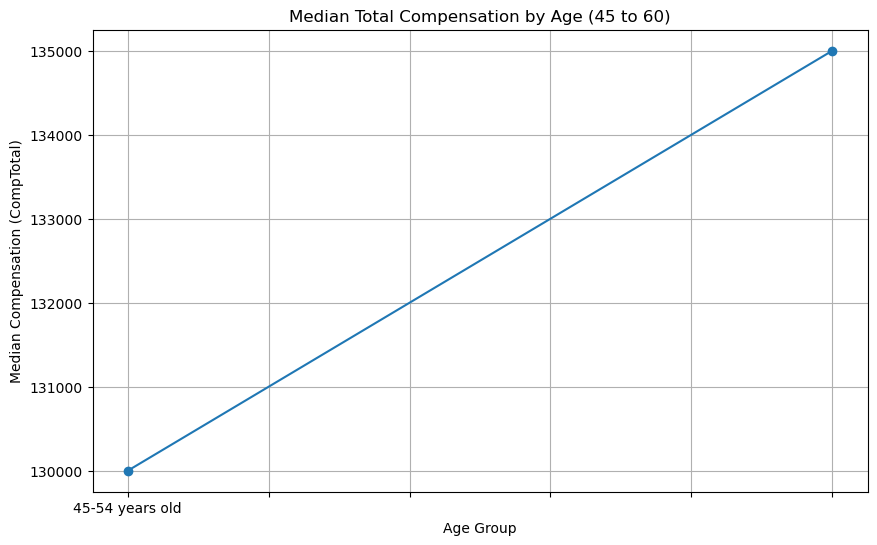

In [66]:
## Write your code here

conn = sqlite3.connect('survey-data.sqlite')
QUERY = "SELECT Age, CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)
conn.close()

# Drop rows with missing values
df = df.dropna(subset=['Age', 'CompTotal'])

# Map Age to numeric midpoint
age_map = {
    'Under 18 years old': 16,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70,
    'Prefer not to say': None
}
df['AgeNumeric'] = df['Age'].map(age_map)

# Filter ages between 45 and 60
df_filtered = df[(df['AgeNumeric'] >= 45) & (df['AgeNumeric'] <= 60)]

# Calculate median CompTotal by Age group
median_comp = df_filtered.groupby('Age')['CompTotal'].median().sort_index()

# Plot line chart
plt.figure(figsize=(10,6))
median_comp.plot(kind='line', marker='o')
plt.title('Median Total Compensation by Age (45 to 60)')
plt.xlabel('Age Group')
plt.ylabel('Median Compensation (CompTotal)')
plt.grid(True)
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


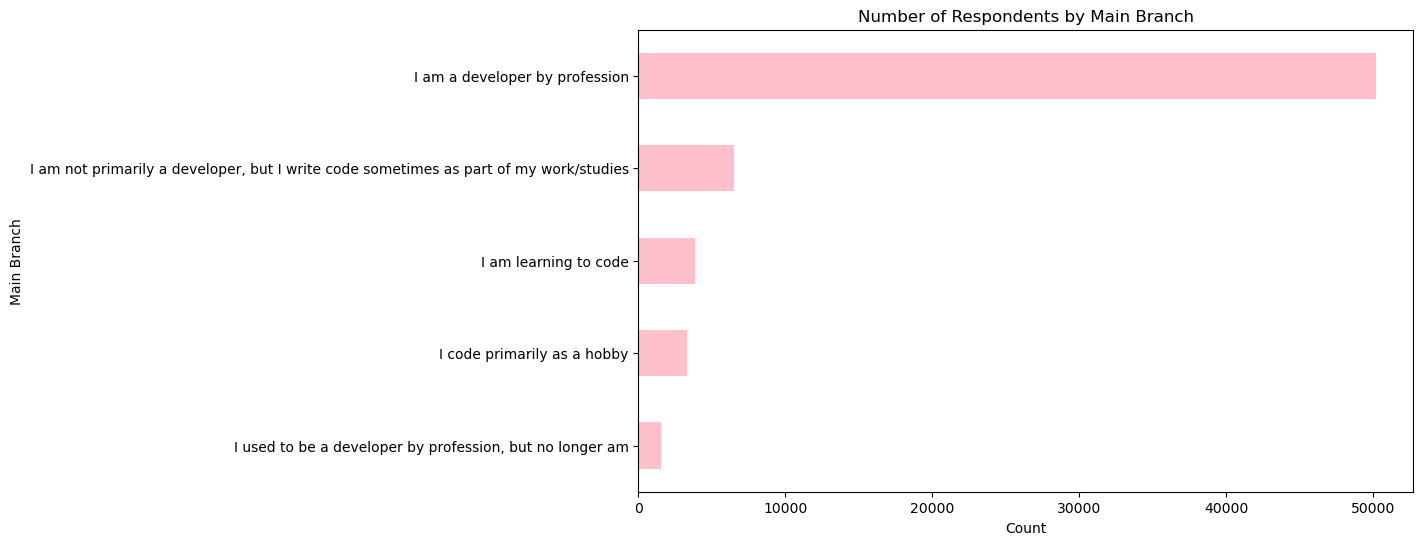

In [68]:
## Write your code here

conn = sqlite3.connect('survey-data.sqlite')
QUERY = "SELECT MainBranch FROM main"
df = pd.read_sql_query(QUERY, conn)
conn.close()

# Count occurrences of each category in MainBranch
branch_counts = df['MainBranch'].value_counts()

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
branch_counts.plot(kind='barh', color='pink')
plt.title('Number of Respondents by Main Branch')
plt.xlabel('Count')
plt.ylabel('Main Branch')
plt.gca().invert_yaxis()  # To have the highest count at the top
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
